In [1]:
!pip install pytesseract

In [2]:
import pytesseract
from PIL import Image


In [3]:
# Load your image 
image_path = "testData/a2.jpg"
image = Image.open(image_path)

In [4]:
# Load the image
img = Image.open("/root/pytesseract/testData/a2.jpg")

# Convert to grayscale
gray_img = img.convert("L")  # 'L' mode means grayscale

# OCR the grayscale image
text = pytesseract.image_to_string(gray_img)
print("=== OCR Output on Grayscale Image (PIL) ===")
print(text)

=== OCR Output on Grayscale Image (PIL) ===
T-112K9S5H5
Spot

@ 7067 HAMBURG, Pennsyivania 19526
Sun, Aug 18, 07:30 EDT
+

@ ETS PONTIAC, Michigan 48342
Mon, Aug 19, 03:04 EDT

Starts in
8h 11m

560 mi
1d 2h

53' Trailer ‘P
Drop/Live

$847,46
$1.51/mi

A. Nurov




In [5]:
# 1. Basic OCR - Extract raw text
text = pytesseract.image_to_string(image)
print("=== Extracted Text ===")
print(text)

=== Extracted Text ===
T-112K9S5H5
Spot

@ 2061 HAMBURG, Pennsylvania 19526
‘Sun, Aug 18, 01:30 €DT
+

@ ETS PONTIAC, Michigan 48342
Mon, Aug 19, 03:04 EDT

Starts in
hm

560 mi
1d 2h

53' Trailer ‘P
Drop/Live

$847,46
$1.51/mi

A. Nurov




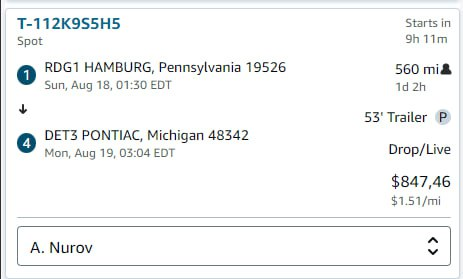

In [6]:
image


In [7]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [8]:
import pandas as pd

# Perform OCR and get TSV output
tsv_data = pytesseract.image_to_data(image)

# Convert TSV string into a pandas DataFrame
from io import StringIO
df = pd.read_csv(StringIO(tsv_data), sep="\t")

# Show nicely formatted
print(df.head(20))   # Only first 20 rows


    level  page_num  block_num  par_num  line_num  word_num  left  top  width  \
0       1         1          0        0         0         0     0    0    463   
1       2         1          1        0         0         0    17   18    103   
2       3         1          1        1         0         0    17   18    103   
3       4         1          1        1         1         0    17   18    103   
4       5         1          1        1         1         1    17   18    103   
5       4         1          1        1         2         0    18   37     24   
6       5         1          1        1         2         1    18   37     24   
7       2         1          2        0         0         0    17   61    269   
8       3         1          2        1         0         0    17   61    269   
9       4         1          2        1         1         0    17   61    269   
10      5         1          2        1         1         1    17   65     19   
11      5         1         

In [9]:
# 2. Word-level data (text + positions + confidence)
print("\n=== Word-level Data (image_to_data) ===")
data = pytesseract.image_to_data(image)
print(data)


=== Word-level Data (image_to_data) ===
level	page_num	block_num	par_num	line_num	word_num	left	top	width	height	conf	text
1	1	0	0	0	0	0	0	463	279	-1	
2	1	1	0	0	0	17	18	103	29	-1	
3	1	1	1	0	0	17	18	103	29	-1	
4	1	1	1	1	0	17	18	103	11	-1	
5	1	1	1	1	1	17	18	103	11	80.970161	T-112K9S5H5
4	1	1	1	2	0	18	37	24	10	-1	
5	1	1	1	2	1	18	37	24	10	95.665344	Spot
2	1	2	0	0	0	17	61	269	53	-1	
3	1	2	1	0	0	17	61	269	53	-1	
4	1	2	1	1	0	17	61	269	24	-1	
5	1	2	1	1	1	17	65	19	20	92.638138	@
5	1	2	1	1	2	45	62	33	10	75.630592	2061
5	1	2	1	1	3	85	62	69	12	95.566689	HAMBURG,
5	1	2	1	1	4	160	61	80	14	8.272087	Pennsylvania
5	1	2	1	1	5	247	62	39	10	95.850266	19526
4	1	2	1	2	0	45	81	126	10	-1	
5	1	2	1	2	1	45	81	19	8	78.685654	‘Sun,
5	1	2	1	2	2	71	81	21	10	96.773735	Aug
5	1	2	1	2	3	98	81	11	8	88.010483	18,
5	1	2	1	2	4	117	81	29	8	84.828819	01:30
5	1	2	1	2	5	153	81	18	8	66.412140	€DT
4	1	2	1	3	0	19	104	8	10	-1	
5	1	2	1	3	1	19	104	8	10	69.544151	+
2	1	3	0	0	0	17	129	231	31	-1	
3	1	3	1	0	0	17	129	231	31	-1	
4	1	3	1	1

In [10]:
import pandas as pd
import pytesseract
from PIL import Image

# Load your image
image_path = "testData/a2.jpg"
image = Image.open(image_path)

# Get character box data
boxes_text = pytesseract.image_to_boxes(image)

# Parse into structured rows
boxes_data = []
for line in boxes_text.strip().split('\n'):
    parts = line.split()
    if len(parts) == 6:
        char, x1, y1, x2, y2, page = parts
        boxes_data.append([char, int(x1), int(y1), int(x2), int(y2), int(page)])

# Create DataFrame
df_boxes = pd.DataFrame(boxes_data, columns=["Character", "x1", "y1", "x2", "y2", "Page"])

print(df_boxes.head(15))  # See first 15 characters


   Character   x1   y1   x2   y2  Page
0          T   17  250   27  261     0
1          -   27  253   32  255     0
2          1   34  250   40  261     0
3          1   43  250   49  261     0
4          2   52  250   60  261     0
5          K   62  250   71  261     0
6          9   72  250   80  261     0
7          S   82  250   90  261     0
8          5   91  250   99  261     0
9          H  101  250  110  261     0
10         5  112  250  120  261     0
11         S   18  234   23  242     0
12         p   25  232   30  240     0
13         o   32  234   37  240     0
14         t   39  234   42  241     0


In [11]:
pip install matplotlib


Note: you may need to restart the kernel to use updated packages.


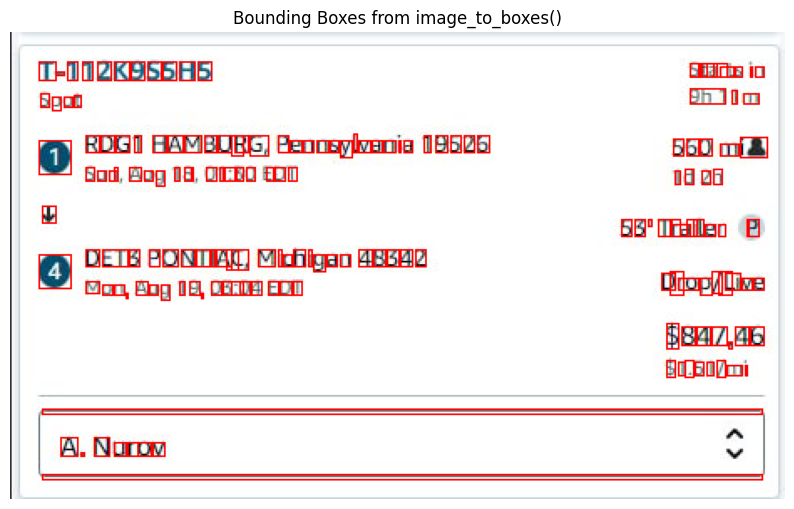

In [12]:
from PIL import Image, ImageDraw
import pytesseract
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image_path = "testData/a2.jpg"
image = Image.open(image_path)

# Optional: Convert to RGB
image = image.convert('RGB')

# OCR to get bounding boxes
boxes = pytesseract.image_to_boxes(image)

# Draw the boxes
draw = ImageDraw.Draw(image)
for box in boxes.splitlines():
    b = box.split()
    left, bottom, right, top = int(b[1]), int(b[2]), int(b[3]), int(b[4])
    draw.rectangle([left, image.height - top, right, image.height - bottom], outline='red')

# Convert to numpy array
img_numpy = np.asarray(image)

# Plot the image
plt.figure(figsize=(10, 8))
plt.imshow(img_numpy)
plt.axis('off')
plt.title('Bounding Boxes from image_to_boxes()')
plt.show()


In [13]:
# 4. Orientation and script detection
print("\n=== Orientation & Script (image_to_osd) ===")
try:
    osd = pytesseract.image_to_osd(image)
    print(osd)
except pytesseract.TesseractError:
    print("OSD not available (might require newer Tesseract model).")


=== Orientation & Script (image_to_osd) ===
Page number: 0
Orientation in degrees: 180
Rotate: 180
Orientation confidence: 0.16
Script: Japanese
Script confidence: 0.50

